1. Dùng camera đt, ghi lại một video dài 5s, tạm đặt tên sample.avi 30fps.

2. Sử dụng kĩ thuật Subtraction với khoản cách 5, 10, 15 frames hiển thị kết quả.

3. Sử dụng kĩ thuật Average Smoothing theo 5 khung hình và hiển thị kết quả.

4. Sử dụng imhist để  hiển thị histogram của tất cả các kkhung hình của video gốc.

5. Sử dụng adapthisteq để điêiuf chỉnh côntrast của các frames trước/sau khi hiệu chỉnh.

6. Chọn 1 frame bất kì. Xây dựng phương pháp smooth frame bằng cách:
    - Random 10% vị trí trong ảnh làm điểm ảnh đánh dấu
    - Tính giá trị điểm ảnh đánh dấu bằng cách lấy gtri trung bình của tất cacr các điểm ảnh trong một cưat sổ trượt với kích thước cố định 5x5.

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

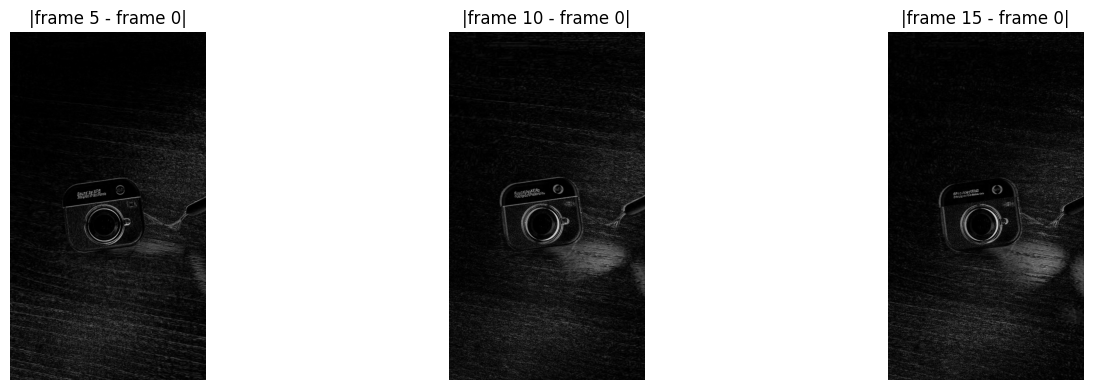

In [28]:
# Cau 2: Subtraction voi khoang cach 5, 10, 15 frames
video_path = Path("sample.avi")
if not video_path.exists():
    raise FileNotFoundError("Khong tim thay sample.avi trong thu muc hien tai.")

cap = cv2.VideoCapture(str(video_path))
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames.append(gray)
cap.release()

if len(frames) < 16:
    raise ValueError("Video can it nhat 16 frames de tru khoang cach 15.")

def show_images(images, titles, cmap="gray", figsize=(15, 4)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

distances = [5, 10, 15]
subtraction_results = []
for d in distances:
    diff = cv2.absdiff(frames[d], frames[0])
    subtraction_results.append(diff)

show_images(
    subtraction_results,
    [f"|frame {d} - frame 0|" for d in distances]
 )

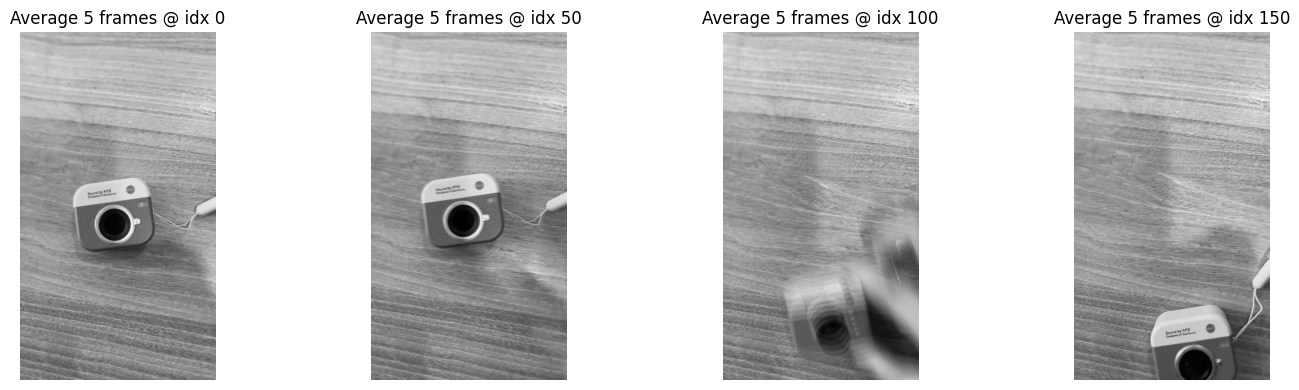

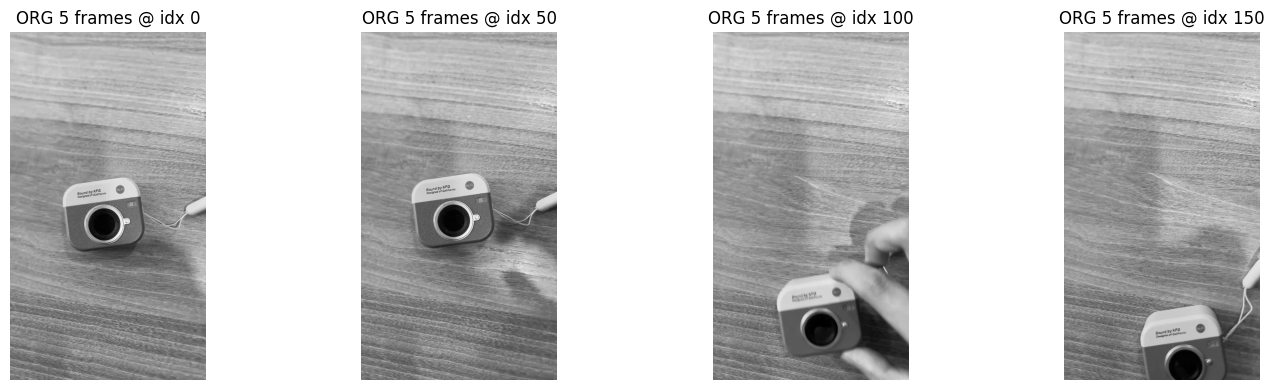

In [35]:
# Cau 3: Average Smoothing theo 5 khung hinh va hien thi ket qua

frs = []
avg5_frames = []
for i in range(len(frames)):
    start = max(0, i - 2)
    end = min(len(frames), i + 3)
    frs.append(frames[start:end])
    avg_frame = np.mean(np.stack(frames[start:end], axis=0), axis=0).astype(np.uint8)
    avg5_frames.append(avg_frame)

sample_idx = np.linspace(0, len(frames) - 1, num=min(4, len(frames)), dtype=int)
imgs = [avg5_frames[i] for i in sample_idx]
titles = [f"Average 5 frames @ idx {i}" for i in sample_idx]
show_images(imgs, titles)

org =  [f"ORG 5 frames @ idx {i}" for i in sample_idx]
show_images([frames[i] for i in sample_idx], org)


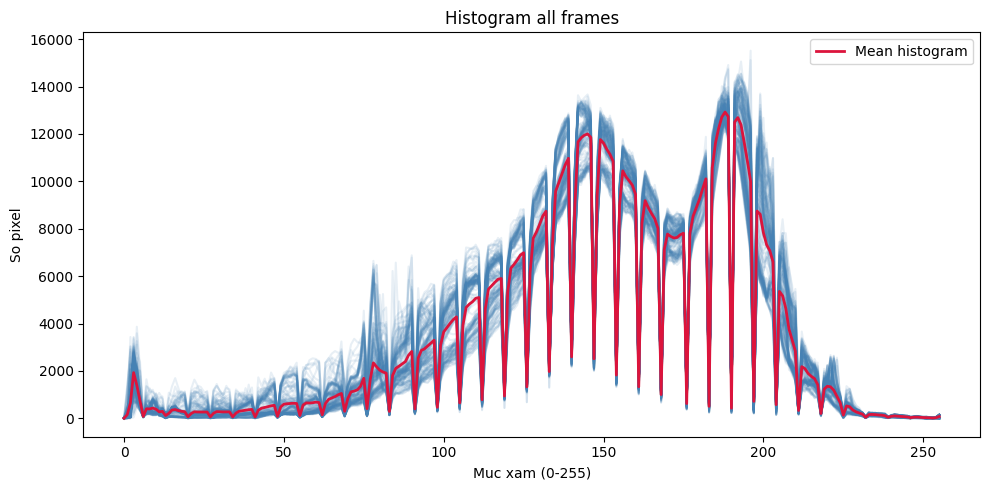

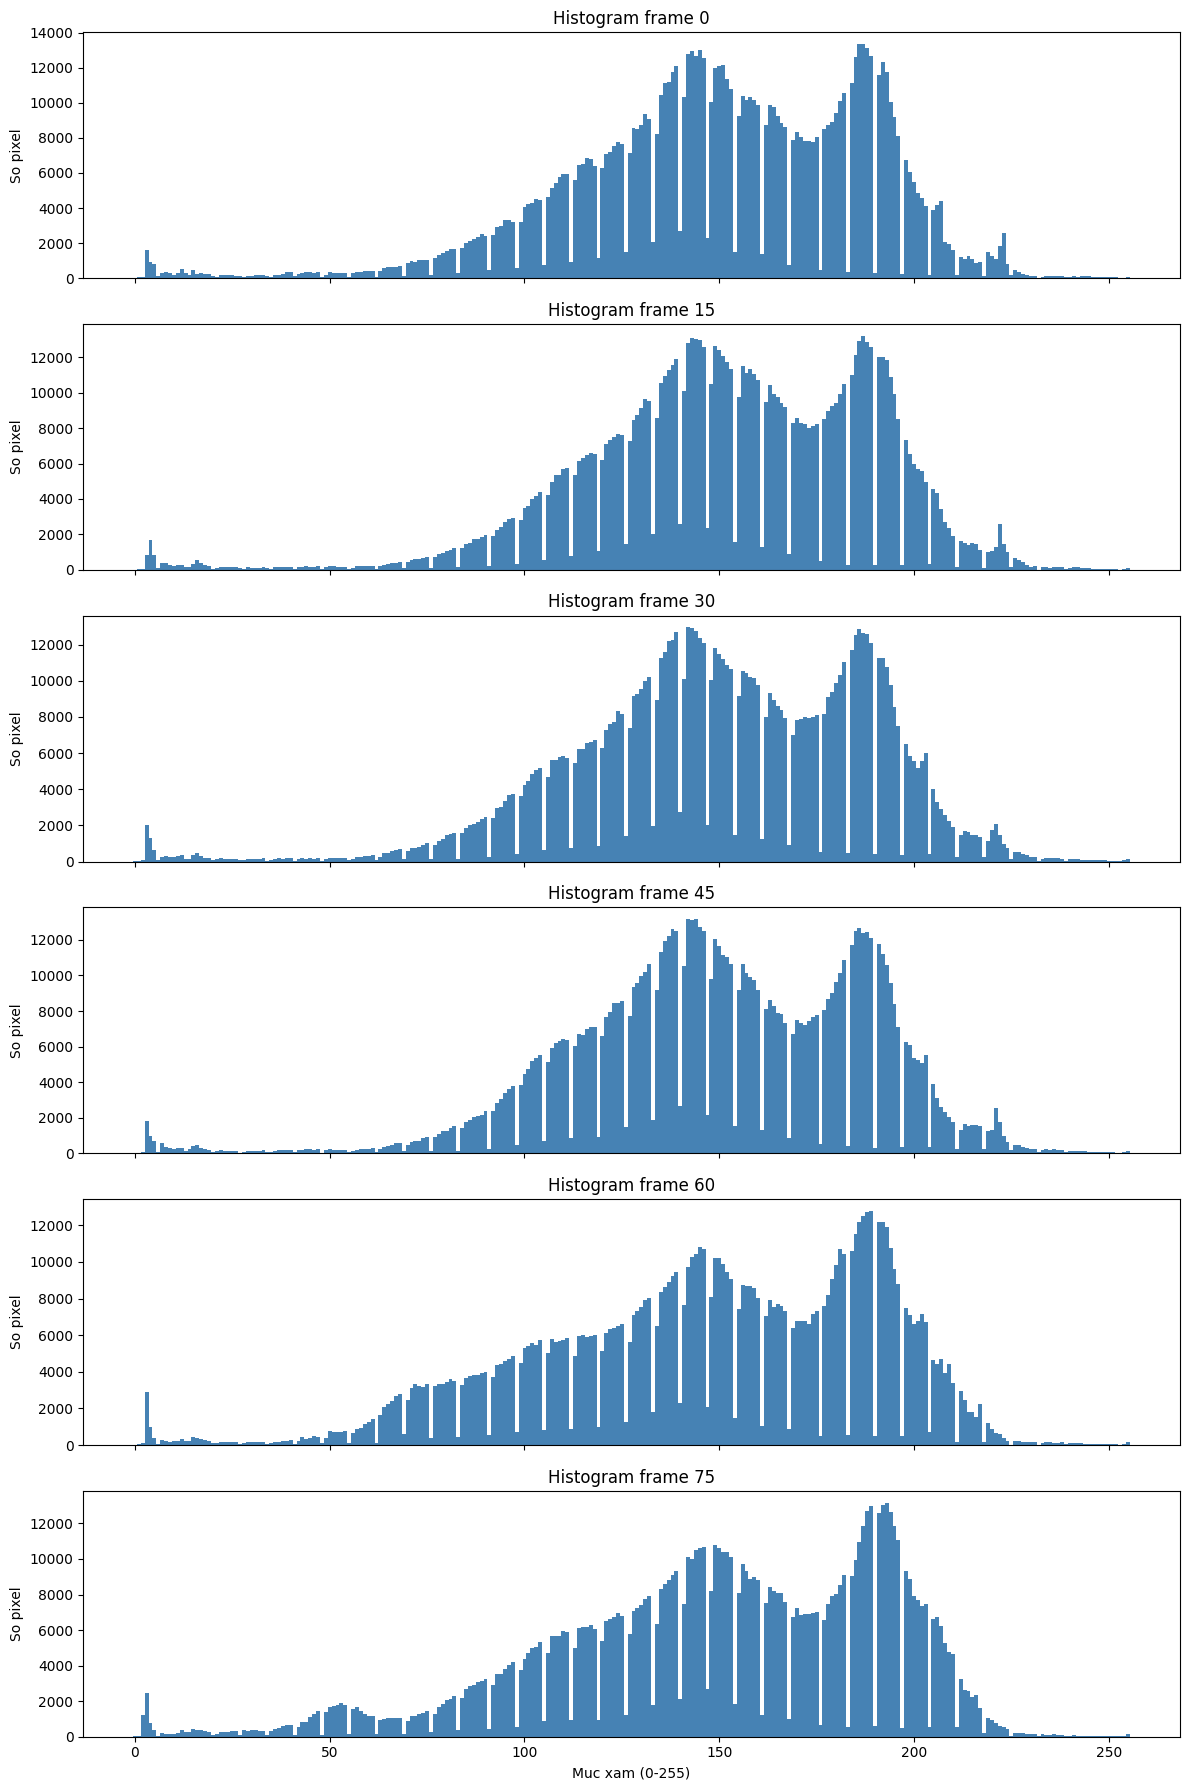

In [30]:
# Cau 4: Hien thi histogram (imhist) cua tat ca khung hinh video goc

all_hists = []
for frame in frames:
    hist = cv2.calcHist([frame], [0], None, [256], [0, 256]).flatten()
    all_hists.append(hist)

plt.figure(figsize=(10, 5))
for hist in all_hists:
    plt.plot(hist, color="steelblue", alpha=0.12)

mean_hist = np.mean(np.stack(all_hists, axis=0), axis=0)
plt.plot(mean_hist, color="crimson", linewidth=2, label="Mean histogram")
plt.title("Histogram all frames")
plt.xlabel("Muc xam (0-255)")
plt.ylabel("So pixel")
plt.legend()
plt.tight_layout()
plt.show()

sample_idx = list(range(0, len(frames), 15))[:6]
fig, axes = plt.subplots(len(sample_idx), 1, figsize=(12, 3 * len(sample_idx)), sharex=True)
if len(sample_idx) == 1:
    axes = [axes]
for ax, idx in zip(axes, sample_idx):
    ax.bar(np.arange(256), all_hists[idx], width=1.0, color="steelblue")
    ax.set_title(f"Histogram frame {idx}")
    ax.set_ylabel("So pixel")
axes[-1].set_xlabel("Muc xam (0-255)")
plt.tight_layout()
plt.show()

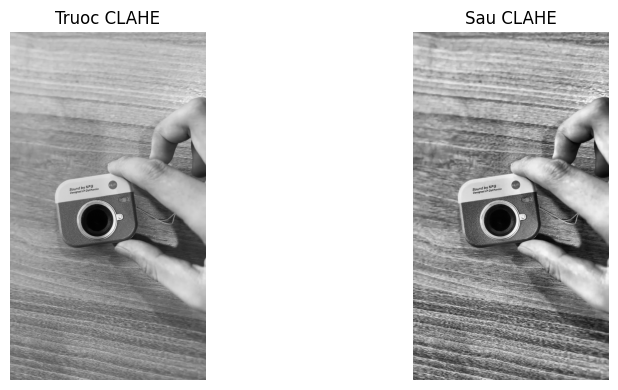

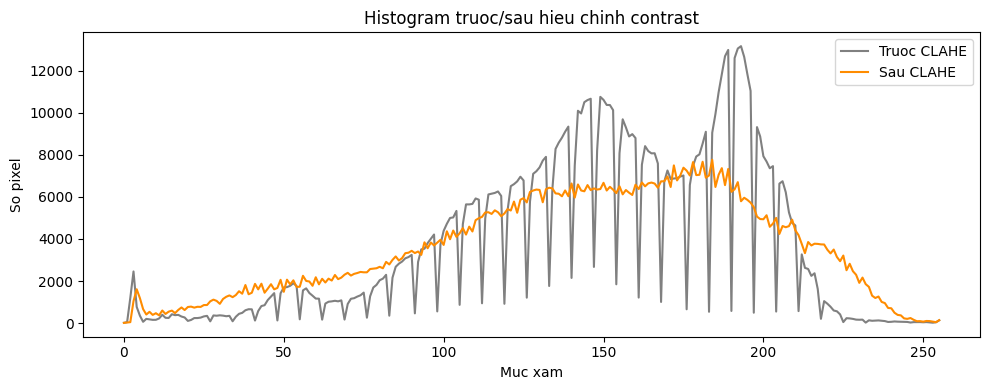

In [31]:
# Cau 5: Dung adapthisteq (tuong duong CLAHE) de chinh contrast truoc/sau
if "frames" not in globals() or len(frames) == 0:
    raise RuntimeError("Hay chay cell cau 2 truoc de nap frames.")

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_frames = [clahe.apply(f) for f in frames]

idx = len(frames) // 2
before = frames[idx]
after = enhanced_frames[idx]

show_images([before, after], ["Truoc CLAHE", "Sau CLAHE"], figsize=(10, 4))

hist_before = cv2.calcHist([before], [0], None, [256], [0, 256]).flatten()
hist_after = cv2.calcHist([after], [0], None, [256], [0, 256]).flatten()

plt.figure(figsize=(10, 4))
plt.plot(hist_before, label="Truoc CLAHE", color="gray")
plt.plot(hist_after, label="Sau CLAHE", color="darkorange")
plt.title("Histogram truoc/sau hieu chinh contrast")
plt.xlabel("Muc xam")
plt.ylabel("So pixel")
plt.legend()
plt.tight_layout()
plt.show()

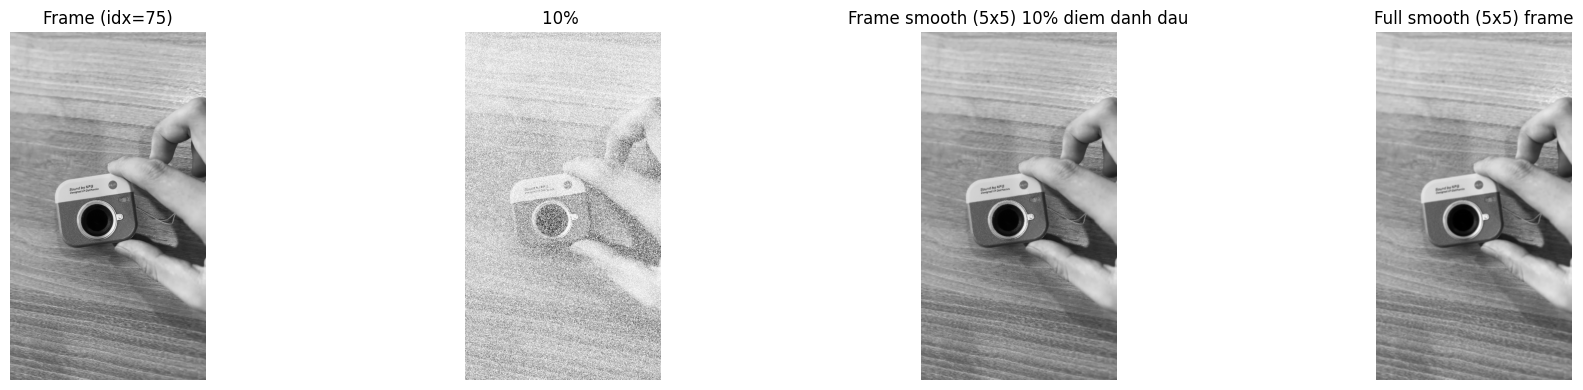

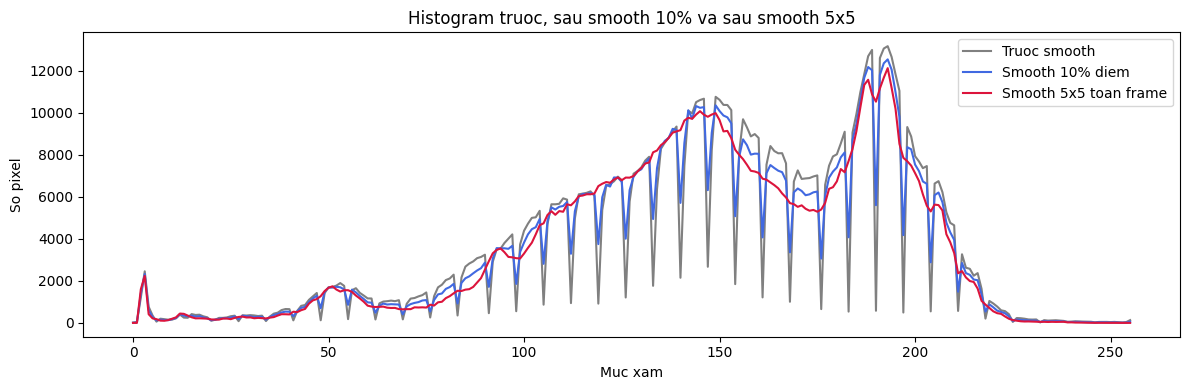

In [36]:
# Cau 6: Smooth 1 frame voi 10% diem danh dau, cua so 5x5 va padding doi xung 2 pixel (thu cong)

def symmetric_index(i, n):
    while i < 0 or i >= n:
        if i < 0:
            i = -i - 1
        else:
            i = 2 * n - i - 1
    return i

def padding(img, pad):
    h, w = img.shape
    out = np.empty((h + 2 * pad, w + 2 * pad), dtype=img.dtype)

    for r in range(h + 2 * pad):
        src_r = symmetric_index(r - pad, h)
        for c in range(w + 2 * pad):
            src_c = symmetric_index(c - pad, w)
            out[r, c] = img[src_r, src_c]

    return out

# Chon 1 frame bat ky (o day lay frame giua)
frame_idx = len(frames) // 2
frame = frames[frame_idx].copy()
h, w = frame.shape

# Random 10% vi tri pixel de danh dau
rng = np.random.default_rng(42)
num_marked = int(0.5 * h * w)
marked_linear_idx = rng.choice(h * w, size=num_marked, replace=False)
marked_mask = np.zeros(h * w, dtype=bool)
marked_mask[marked_linear_idx] = True
marked_mask = marked_mask.reshape(h, w)

# Padding doi xung 2 pixel thu cong cho kernel 5x5
pad = 2
padded = padding(frame, pad)

# Duyet anh goc (toa do trong anh pad bat dau tu (2,2))
smoothed_frame = frame.copy().astype(np.float32)
rows, cols = np.where(marked_mask)
for r, c in zip(rows, cols):
    rr = r + pad
    cc = c + pad
    window = padded[rr - 2:rr + 3, cc - 2:cc + 3]
    smoothed_frame[r, c] = np.mean(window)

smoothed_frame = np.clip(smoothed_frame, 0, 255).astype(np.uint8)

# Smooth 5x5 
full_smoothed = np.empty((h, w), dtype=np.float32)
for r in range(h):
    for c in range(w):
        rr = r + pad
        cc = c + pad
        window = padded[rr - 2:rr + 3, cc - 2:cc + 3]
        full_smoothed[r, c] = np.mean(window)
full_smoothed = np.clip(full_smoothed, 0, 255).astype(np.uint8)

# Hien thi ket qua
overlay = frame.copy()
overlay[marked_mask] = 255

show_images(
    [frame, overlay, smoothed_frame, full_smoothed],
    [
        f"Frame (idx={frame_idx})",
        "10% ",
        "Frame smooth (5x5) 10% diem danh dau",
        "Full smooth (5x5) frame",
    ],
    figsize=(20, 4),
)


hist_before = cv2.calcHist([frame], [0], None, [256], [0, 256]).flatten()
hist_smoothed_10 = cv2.calcHist([smoothed_frame], [0], None, [256], [0, 256]).flatten() # smooth 10% điểm ảnh đã đánh dấu
hist_smoothed_5x5 = cv2.calcHist([full_smoothed], [0], None, [256], [0, 256]).flatten() #smooth full frames

plt.figure(figsize=(12, 4))
plt.plot(hist_before, label="Truoc smooth", color="gray")
plt.plot(hist_smoothed_10, label="Smooth 10% diem", color="royalblue")
plt.plot(hist_smoothed_5x5, label="Smooth 5x5 toan frame", color="crimson")
plt.title("Histogram truoc, sau smooth 10% va sau smooth 5x5")
plt.xlabel("Muc xam")
plt.ylabel("So pixel")
plt.legend()
plt.tight_layout()
plt.show()